In [1]:
from __future__ import annotations

from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import pandas as pd

root = Path('..').resolve()
DATA_DIR = root / 'data'
sys.path.append(str(root))
PROCESSED_PATH = DATA_DIR / 'processed_v2.csv'
LABELS_PATH = DATA_DIR / 'labels.csv'
SPLIT_DIR = DATA_DIR / 'sample'
DOCS_DIR = root / "docs"
SPLIT_MANIFEST_PATH = DOCS_DIR / "splits_manifest_lab5.json"

In [2]:
def build_split_distribution(frame: pd.DataFrame, split_name: str) -> pd.DataFrame:
    counts = frame["dominant_label"].value_counts(dropna=False).rename_axis("label").reset_index(name="count")
    counts["split"] = split_name
    counts["share"] = (counts["count"] / counts["count"].sum()).round(4)
    return counts[["split", "label", "count", "share"]]


def metric_row(model_name: str, split_name: str, metrics: dict[str, float]) -> dict[str, float | str]:
    return {
        "model": model_name,
        "split": split_name,
        "accuracy": metrics["accuracy"],
        "macro_f1": metrics["macro_f1"],
    }


def plot_confusion_df(cm_df: pd.DataFrame, title: str) -> None:
    plt.figure(figsize=(7, 6))
    plt.imshow(cm_df.values, cmap="Blues")
    plt.xticks(range(len(cm_df.columns)), cm_df.columns, rotation=45, ha="right")
    plt.yticks(range(len(cm_df.index)), cm_df.index)
    plt.title(title)
    plt.colorbar()

    for i in range(len(cm_df.index)):
        for j in range(len(cm_df.columns)):
            plt.text(j, i, str(cm_df.iloc[i, j]), ha="center", va="center", fontsize=8)

    plt.xlabel("Predicted")
    plt.ylabel("Gold")
    plt.tight_layout()
    plt.show()

In [ ]:
from src.classification_baseline import (
    attach_labels,
    filter_by_ids,
    load_labels,
    load_processed,
    load_split_ids,
)

processed = load_processed(PROCESSED_PATH)
labels = load_labels(LABELS_PATH)
data = attach_labels(processed, labels)
splits = load_split_ids(SPLIT_DIR)

train_df = filter_by_ids(data, splits["train"])
val_df = filter_by_ids(data, splits["val"])
test_df = filter_by_ids(data, splits["test"])

with SPLIT_MANIFEST_PATH.open("r", encoding="utf-8") as f:
    split_manifest = json.load(f)

actual_sizes = {
    "train": len(train_df),
    "val": len(val_df),
    "test": len(test_df),
}

print("Split sizes:", actual_sizes)
print("Manifest sizes:", split_manifest["sizes"])

Split sizes: {'train': 8929, 'val': 1116, 'test': 1116}
Manifest sizes: {'train': 8929, 'val': 1116, 'test': 1116}


In [4]:
label_distribution = pd.concat([
    build_split_distribution(train_df, "train"),
    build_split_distribution(val_df, "val"),
    build_split_distribution(test_df, "test"),
], ignore_index=True)

label_distribution

,split,label,count,share
0,train,NO_ENTITY,4657,0.5216
1,train,PERS,1348,0.1510
2,train,ORG,804,0.0900
3,train,LOC,684,0.0766
4,train,DATE,406,0.0455
5,train,JOB,338,0.0379
6,train,ART,188,0.0211
7,train,MISC,151,0.0169
8,train,MON,144,0.0161
9,train,PERIOD,88,0.0099


In [5]:
from src.classification_baseline import (
    BaselineConfig,
    build_pipeline,
    evaluate_split,
    full_report,
    get_confusion,
    top_features,
)

X_train = train_df["text_clean"].fillna("")
y_train = train_df["dominant_label"]
X_val = val_df["text_clean"].fillna("")
y_val = val_df["dominant_label"]
X_test = test_df["text_clean"].fillna("")
y_test = test_df["dominant_label"]

In [6]:
lab6_baseline_cfg = BaselineConfig(
    analyzer="word",
    ngram_range=(1, 2),
    sublinear_tf=True,
    max_iter=400,
    class_weight=None,
)

lab6_baseline = build_pipeline(lab6_baseline_cfg)
lab6_baseline.fit(X_train, y_train)

baseline_metrics = pd.DataFrame([
    metric_row("LogReg baseline", "train", evaluate_split(lab6_baseline, X_train, y_train)),
    metric_row("LogReg baseline", "val", evaluate_split(lab6_baseline, X_val, y_val)),
    metric_row("LogReg baseline", "test", evaluate_split(lab6_baseline, X_test, y_test)),
])

baseline_metrics

,model,split,accuracy,macro_f1
0,LogReg baseline,train,0.695935,0.310652
1,LogReg baseline,val,0.620072,0.232223
2,LogReg baseline,test,0.614695,0.216238


In [7]:
print("Validation report")
print(full_report(lab6_baseline, X_val, y_val))

print("Test report")
print(full_report(lab6_baseline, X_test, y_test))

Validation report
              precision    recall  f1-score   support

         ART       0.88      0.30      0.45        23
        DATE       0.67      0.43      0.52        51
         DOC       0.00      0.00      0.00         5
         JOB       0.00      0.00      0.00        42
         LOC       0.56      0.06      0.11        86
        MISC       0.00      0.00      0.00        19
         MON       0.83      0.56      0.67        18
   NO_ENTITY       0.62      0.99      0.76       582
         ORG       0.51      0.45      0.48       100
         PCT       0.00      0.00      0.00         4
      PERIOD       0.00      0.00      0.00        11
        PERS       0.71      0.16      0.26       168
       QUANT       0.00      0.00      0.00         6
        TIME       0.00      0.00      0.00         1

    accuracy                           0.62      1116
   macro avg       0.34      0.21      0.23      1116
weighted avg       0.58      0.62      0.53      1116

Test re

/home/user/lababd7/venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/user/lababd7/venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/user/lababd7/venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/user

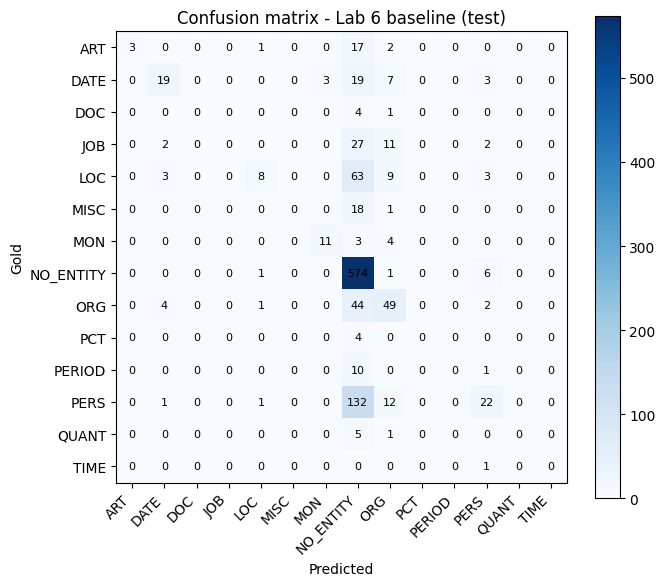

,ART,DATE,DOC,JOB,LOC,MISC,MON,NO_ENTITY,ORG,PCT,PERIOD,PERS,QUANT,TIME
ART,3,0,0,0,1,0,0,17,2,0,0,0,0,0
DATE,0,19,0,0,0,0,3,19,7,0,0,3,0,0
DOC,0,0,0,0,0,0,0,4,1,0,0,0,0,0
JOB,0,2,0,0,0,0,0,27,11,0,0,2,0,0
LOC,0,3,0,0,8,0,0,63,9,0,0,3,0,0
MISC,0,0,0,0,0,0,0,18,1,0,0,0,0,0
MON,0,0,0,0,0,0,11,3,4,0,0,0,0,0
NO_ENTITY,0,0,0,0,1,0,0,574,1,0,0,6,0,0
ORG,0,4,0,0,1,0,0,44,49,0,0,2,0,0
PCT,0,0,0,0,0,0,0,4,0,0,0,0,0,0


In [8]:
baseline_cm_df, baseline_labels = get_confusion(lab6_baseline, X_test, y_test)
plot_confusion_df(baseline_cm_df, "Confusion matrix - Lab 6 baseline (test)")
baseline_cm_df

In [9]:
baseline_top_features = top_features(lab6_baseline, top_k=10, negative=False)
baseline_top_features_df = pd.DataFrame(
    [
        {"label": label, "feature": feature, "weight": weight}
        for label, items in baseline_top_features.items()
        for feature, weight in items
    ]
)
baseline_top_features_df

,label,feature,weight
0,ART,про це,3.091566
1,ART,це,2.220733
2,ART,про,2.016123
3,ART,віснику,1.521984
4,ART,це пише,1.490564
...,...,...,...
135,TIME,день,0.354989
136,TIME,би вона,0.325019
137,TIME,ятнадцять хвилин,0.325019
138,TIME,на ятнадцять,0.325019


,model,features,class_weight,split,accuracy,macro_f1
0,LogReg baseline,"word(1,2)",none,train,0.695935,0.310652
1,LogReg baseline,"word(1,2)",none,val,0.620072,0.232223
2,LogReg baseline,"word(1,2)",none,test,0.614695,0.216238
3,"LinearSVC word(1,2)","word(1,2)",none,train,0.999552,0.998144
4,"LinearSVC word(1,2)","word(1,2)",none,val,0.694444,0.343207
5,"LinearSVC word(1,2)","word(1,2)",none,test,0.679211,0.374466


,model,features,class_weight,split,accuracy,macro_f1
4,"LinearSVC word(1,2)","word(1,2)",none,val,0.694444,0.343207
1,LogReg baseline,"word(1,2)",none,val,0.620072,0.232223


Validation report - LinearSVC word(1,2)
              precision    recall  f1-score   support

         ART       0.75      0.39      0.51        23
        DATE       0.57      0.55      0.56        51
         DOC       0.00      0.00      0.00         5
         JOB       0.56      0.12      0.20        42
         LOC       0.64      0.31      0.42        86
        MISC       1.00      0.11      0.19        19
         MON       0.65      0.72      0.68        18
   NO_ENTITY       0.75      0.94      0.83       582
         ORG       0.53      0.66      0.59       100
         PCT       0.00      0.00      0.00         4
      PERIOD       0.00      0.00      0.00        11
        PERS       0.63      0.46      0.53       168
       QUANT       1.00      0.17      0.29         6
        TIME       0.00      0.00      0.00         1

    accuracy                           0.69      1116
   macro avg       0.51      0.32      0.34      1116
weighted avg       0.68      0.69      0

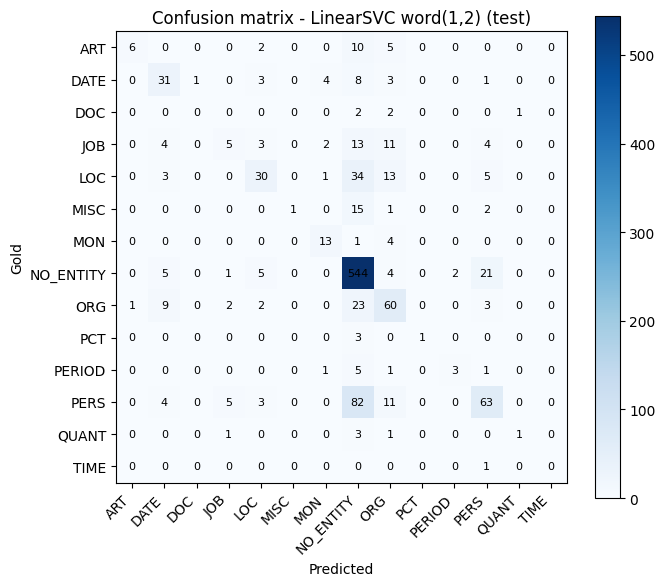

,label,feature,weight
0,ART,sofia,1.466603
1,ART,про це,1.427875
2,ART,це пише,1.265913
3,ART,пише,1.166849
4,ART,наших грошей,1.152211
...,...,...,...
135,TIME,до восьмої,0.453557
136,TIME,закінчиться це,0.453557
137,TIME,закінчиться,0.453557
138,TIME,восьмої,0.453557


In [10]:
from IPython.display import display

from src.svm_experiments import (
    LinearSVCConfig,
    full_report as svm_full_report,
    get_confusion as get_svm_confusion,
    run_linear_svc,
    top_features as top_svm_features,
)

svm_word_cfg = LinearSVCConfig(
    analyzer="word",
    ngram_range=(1, 2),
    sublinear_tf=True,
    C=1.0,
    class_weight=None,
)

svm_word_model, svm_word_metrics = run_linear_svc(
    X_train,
    y_train,
    X_val,
    y_val,
    X_test,
    y_test,
    cfg=svm_word_cfg,
    model_name="LinearSVC word(1,2)",
)

baseline_comparison = baseline_metrics.copy()
baseline_comparison["features"] = "word(1,2)"
baseline_comparison["class_weight"] = "none"

svm_word_comparison = svm_word_metrics.copy()
svm_word_comparison["features"] = "word(1,2)"
svm_word_comparison["class_weight"] = "none"

comparison_metrics = pd.concat([
    baseline_comparison,
    svm_word_comparison,
], ignore_index=True)[["model", "features", "class_weight", "split", "accuracy", "macro_f1"]]

display(comparison_metrics)

val_ranking = comparison_metrics[comparison_metrics["split"] == "val"].sort_values(
    ["macro_f1", "accuracy"], ascending=False
)
display(val_ranking)

print("Validation report - LinearSVC word(1,2)")
print(svm_full_report(svm_word_model, X_val, y_val))

print("Test report - LinearSVC word(1,2)")
print(svm_full_report(svm_word_model, X_test, y_test))

svm_word_cm_df, svm_word_labels = get_svm_confusion(svm_word_model, X_test, y_test)
plot_confusion_df(svm_word_cm_df, "Confusion matrix - LinearSVC word(1,2) (test)")

svm_word_top_features = top_svm_features(svm_word_model, top_k=10, negative=False)
svm_word_top_features_df = pd.DataFrame(
    [
        {"label": label, "feature": feature, "weight": weight}
        for label, items in svm_word_top_features.items()
        for feature, weight in items
    ]
)
display(svm_word_top_features_df)

,model,features,class_weight,split,accuracy,macro_f1
0,LogReg baseline,"word(1,2)",none,train,0.695935,0.310652
1,LogReg baseline,"word(1,2)",none,val,0.620072,0.232223
2,LogReg baseline,"word(1,2)",none,test,0.614695,0.216238
3,"LinearSVC word(1,2)","word(1,2)",none,train,0.999552,0.998144
4,"LinearSVC word(1,2)","word(1,2)",none,val,0.694444,0.343207
5,"LinearSVC word(1,2)","word(1,2)",none,test,0.679211,0.374466
6,"LinearSVC char_wb(3,5)","char_wb(3,5)",none,train,0.998656,0.993874
7,"LinearSVC char_wb(3,5)","char_wb(3,5)",none,val,0.735663,0.389193
8,"LinearSVC char_wb(3,5)","char_wb(3,5)",none,test,0.720430,0.398504
9,"LinearSVC word(1,2)+char_wb(3,5)","word(1,2)+char_wb(3,5)",none,train,0.999664,0.998179


,model,features,class_weight,split,accuracy,macro_f1
10,"LinearSVC word(1,2)+char_wb(3,5)","word(1,2)+char_wb(3,5)",none,val,0.731183,0.390637
7,"LinearSVC char_wb(3,5)","char_wb(3,5)",none,val,0.735663,0.389193
4,"LinearSVC word(1,2)","word(1,2)",none,val,0.694444,0.343207
1,LogReg baseline,"word(1,2)",none,val,0.620072,0.232223


Best SVM by validation macro-F1: LinearSVC word(1,2)+char_wb(3,5) | features: word(1,2)+char_wb(3,5)
Validation report - best SVM candidate
              precision    recall  f1-score   support

         ART       0.69      0.39      0.50        23
        DATE       0.63      0.61      0.62        51
         DOC       0.00      0.00      0.00         5
         JOB       0.69      0.26      0.38        42
         LOC       0.65      0.41      0.50        86
        MISC       1.00      0.11      0.19        19
         MON       0.71      0.67      0.69        18
   NO_ENTITY       0.78      0.96      0.86       582
         ORG       0.58      0.67      0.62       100
         PCT       0.00      0.00      0.00         4
      PERIOD       0.00      0.00      0.00        11
        PERS       0.71      0.54      0.61       168
       QUANT       1.00      0.33      0.50         6
        TIME       0.00      0.00      0.00         1

    accuracy                           0.73     

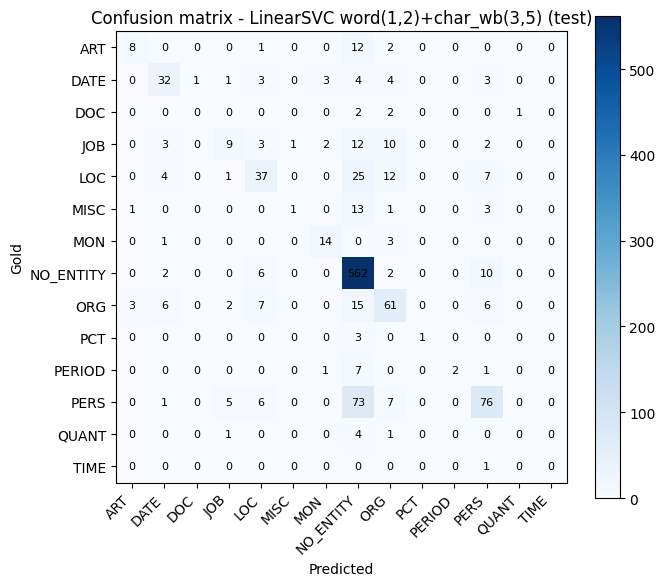

,label,feature,weight
0,ART,word__про це,1.018292
1,ART,word__це пише,0.791082
2,ART,word__sofia,0.762218
3,ART,word__пише,0.721508
4,ART,word__пку,0.622706
...,...,...,...
135,TIME,word__закінчиться,0.291817
136,TIME,word__до восьмої,0.291817
137,TIME,word__фактично день,0.291817
138,TIME,word__восьмої,0.291817


In [11]:
from src.svm_experiments import WordCharLinearSVCConfig, run_word_char_linear_svc

svm_char_cfg = LinearSVCConfig(
    analyzer="char_wb",
    ngram_range=(3, 5),
    sublinear_tf=True,
    C=1.0,
    class_weight=None,
)

svm_char_model, svm_char_metrics = run_linear_svc(
    X_train,
    y_train,
    X_val,
    y_val,
    X_test,
    y_test,
    cfg=svm_char_cfg,
    model_name="LinearSVC char_wb(3,5)",
)

svm_word_char_cfg = WordCharLinearSVCConfig(
    word_ngram_range=(1, 2),
    char_analyzer="char_wb",
    char_ngram_range=(3, 5),
    sublinear_tf=True,
    C=1.0,
    class_weight=None,
)

svm_word_char_model, svm_word_char_metrics = run_word_char_linear_svc(
    X_train,
    y_train,
    X_val,
    y_val,
    X_test,
    y_test,
    cfg=svm_word_char_cfg,
    model_name="LinearSVC word(1,2)+char_wb(3,5)",
)

svm_char_comparison = svm_char_metrics.copy()
svm_char_comparison["features"] = "char_wb(3,5)"
svm_char_comparison["class_weight"] = "none"

svm_word_char_comparison = svm_word_char_metrics.copy()
svm_word_char_comparison["features"] = "word(1,2)+char_wb(3,5)"
svm_word_char_comparison["class_weight"] = "none"

all_model_metrics = pd.concat([
    baseline_comparison,
    svm_word_comparison,
    svm_char_comparison,
    svm_word_char_comparison,
], ignore_index=True)[["model", "features", "class_weight", "split", "accuracy", "macro_f1"]]

display(all_model_metrics)

val_model_ranking = all_model_metrics[all_model_metrics["split"] == "val"].sort_values(
    ["macro_f1", "accuracy"], ascending=False
)
display(val_model_ranking)

svm_candidates = {
    "LinearSVC word(1,2)": {
        "model": svm_word_model,
        "metrics": svm_word_metrics,
        "features": "word(1,2)",
    },
    "LinearSVC char_wb(3,5)": {
        "model": svm_char_model,
        "metrics": svm_char_metrics,
        "features": "char_wb(3,5)",
    },
    "LinearSVC word(1,2)+char_wb(3,5)": {
        "model": svm_word_char_model,
        "metrics": svm_word_char_metrics,
        "features": "word(1,2)+char_wb(3,5)",
    },
}

best_svm_name = (
    val_model_ranking[val_model_ranking["model"].str.startswith("LinearSVC")]
    .iloc[0]["model"]
)
best_svm_model = svm_candidates[best_svm_name]["model"]
best_svm_features = svm_candidates[best_svm_name]["features"]

print(f"Best SVM by validation macro-F1: {best_svm_name} | features: {best_svm_features}")
print("Validation report - best SVM candidate")
print(svm_full_report(best_svm_model, X_val, y_val))

print("Test report - best SVM candidate")
print(svm_full_report(best_svm_model, X_test, y_test))

best_svm_cm_df, best_svm_labels = get_svm_confusion(best_svm_model, X_test, y_test)
plot_confusion_df(best_svm_cm_df, f"Confusion matrix - {best_svm_name} (test)")

best_svm_top_features = top_svm_features(best_svm_model, top_k=10, negative=False)
best_svm_top_features_df = pd.DataFrame(
    [
        {"label": label, "feature": feature, "weight": weight}
        for label, items in best_svm_top_features.items()
        for feature, weight in items
    ]
)
display(best_svm_top_features_df)

In [12]:
from src.svm_experiments import classification_report_df

train_class_counts = train_df["dominant_label"].value_counts().sort_values()
minority_label = train_class_counts.index[0]
tail_labels = train_class_counts.head(5).index.tolist()

imbalance_overview = train_class_counts.rename_axis("label").reset_index(name="train_count")
imbalance_overview["train_share"] = (imbalance_overview["train_count"] / imbalance_overview["train_count"].sum()).round(4)
display(imbalance_overview)

print(f"Minority class in train: {minority_label} | count={int(train_class_counts.iloc[0])}")
print(f"Tail classes used for inspection: {tail_labels}")

if best_svm_name == "LinearSVC word(1,2)":
    best_svm_balanced_cfg = LinearSVCConfig(
        analyzer="word",
        ngram_range=(1, 2),
        sublinear_tf=True,
        C=1.0,
        class_weight="balanced",
    )
    best_svm_balanced_model, best_svm_balanced_metrics = run_linear_svc(
        X_train,
        y_train,
        X_val,
        y_val,
        X_test,
        y_test,
        cfg=best_svm_balanced_cfg,
        model_name=f"{best_svm_name} balanced",
    )
elif best_svm_name == "LinearSVC char_wb(3,5)":
    best_svm_balanced_cfg = LinearSVCConfig(
        analyzer="char_wb",
        ngram_range=(3, 5),
        sublinear_tf=True,
        C=1.0,
        class_weight="balanced",
    )
    best_svm_balanced_model, best_svm_balanced_metrics = run_linear_svc(
        X_train,
        y_train,
        X_val,
        y_val,
        X_test,
        y_test,
        cfg=best_svm_balanced_cfg,
        model_name=f"{best_svm_name} balanced",
    )
else:
    best_svm_balanced_cfg = WordCharLinearSVCConfig(
        word_ngram_range=(1, 2),
        char_analyzer="char_wb",
        char_ngram_range=(3, 5),
        sublinear_tf=True,
        C=1.0,
        class_weight="balanced",
    )
    best_svm_balanced_model, best_svm_balanced_metrics = run_word_char_linear_svc(
        X_train,
        y_train,
        X_val,
        y_val,
        X_test,
        y_test,
        cfg=best_svm_balanced_cfg,
        model_name=f"{best_svm_name} balanced",
    )

best_svm_unbalanced_comparison = svm_candidates[best_svm_name]["metrics"].copy()
best_svm_unbalanced_comparison["features"] = best_svm_features
best_svm_unbalanced_comparison["class_weight"] = "none"

best_svm_balanced_comparison = best_svm_balanced_metrics.copy()
best_svm_balanced_comparison["features"] = best_svm_features
best_svm_balanced_comparison["class_weight"] = "balanced"

class_weight_comparison = pd.concat([
    best_svm_unbalanced_comparison,
    best_svm_balanced_comparison,
], ignore_index=True)[["model", "features", "class_weight", "split", "accuracy", "macro_f1"]]
display(class_weight_comparison)

val_class_weight_ranking = class_weight_comparison[class_weight_comparison["split"] == "val"].sort_values(
    ["macro_f1", "accuracy"], ascending=False
)
display(val_class_weight_ranking)

val_unbalanced_report_df = classification_report_df(best_svm_model, X_val, y_val)
val_balanced_report_df = classification_report_df(best_svm_balanced_model, X_val, y_val)

per_class_compare = (
    val_unbalanced_report_df.rename(
        columns={
            "precision": "precision_none",
            "recall": "recall_none",
            "f1-score": "f1_none",
            "support": "support_none",
        }
    )
    .merge(
        val_balanced_report_df.rename(
            columns={
                "precision": "precision_balanced",
                "recall": "recall_balanced",
                "f1-score": "f1_balanced",
                "support": "support_balanced",
            }
        ),
        on="label",
        how="inner",
    )
)

for column in ["precision", "recall", "f1"]:
    per_class_compare[f"delta_{column}"] = (
        per_class_compare[f"{column}_balanced"] - per_class_compare[f"{column}_none"]
    ).round(4)

focus_labels = tail_labels + [minority_label, "macro avg", "weighted avg"]
focus_labels = list(dict.fromkeys(focus_labels))
focus_class_weight_compare = per_class_compare[per_class_compare["label"].isin(focus_labels)].copy()
display(
    focus_class_weight_compare[
        [
            "label",
            "precision_none",
            "precision_balanced",
            "delta_precision",
            "recall_none",
            "recall_balanced",
            "delta_recall",
            "f1_none",
            "f1_balanced",
            "delta_f1",
            "support_none",
        ]
    ].sort_values("label")
)

minority_compare = focus_class_weight_compare[focus_class_weight_compare["label"] == minority_label]
display(minority_compare)
if not minority_compare.empty:
    minority_row = minority_compare.iloc[0]
    print(
        f"Minority class {minority_label}: precision {minority_row['precision_none']:.3f} -> {minority_row['precision_balanced']:.3f}, "
        f"recall {minority_row['recall_none']:.3f} -> {minority_row['recall_balanced']:.3f}, "
        f"f1 {minority_row['f1_none']:.3f} -> {minority_row['f1_balanced']:.3f}"
    )


print("Validation report - unbalanced best SVM")
print(svm_full_report(best_svm_model, X_val, y_val))

print("Validation report - balanced best SVM")
print(svm_full_report(best_svm_balanced_model, X_val, y_val))

,label,train_count,train_share
0,TIME,7,0.0008
1,PCT,31,0.0035
2,DOC,38,0.0043
3,QUANT,45,0.0050
4,PERIOD,88,0.0099
5,MON,144,0.0161
6,MISC,151,0.0169
7,ART,188,0.0211
8,JOB,338,0.0379
9,DATE,406,0.0455


Minority class in train: TIME | count=7
Tail classes used for inspection: ['TIME', 'PCT', 'DOC', 'QUANT', 'PERIOD']


,model,features,class_weight,split,accuracy,macro_f1
0,"LinearSVC word(1,2)+char_wb(3,5)","word(1,2)+char_wb(3,5)",none,train,0.999664,0.998179
1,"LinearSVC word(1,2)+char_wb(3,5)","word(1,2)+char_wb(3,5)",none,val,0.731183,0.390637
2,"LinearSVC word(1,2)+char_wb(3,5)","word(1,2)+char_wb(3,5)",none,test,0.719534,0.387707
3,"LinearSVC word(1,2)+char_wb(3,5) balanced","word(1,2)+char_wb(3,5)",balanced,train,0.999552,0.997256
4,"LinearSVC word(1,2)+char_wb(3,5) balanced","word(1,2)+char_wb(3,5)",balanced,val,0.733871,0.461591
5,"LinearSVC word(1,2)+char_wb(3,5) balanced","word(1,2)+char_wb(3,5)",balanced,test,0.728495,0.433233


,model,features,class_weight,split,accuracy,macro_f1
4,"LinearSVC word(1,2)+char_wb(3,5) balanced","word(1,2)+char_wb(3,5)",balanced,val,0.733871,0.461591
1,"LinearSVC word(1,2)+char_wb(3,5)","word(1,2)+char_wb(3,5)",none,val,0.731183,0.390637


,label,precision_none,precision_balanced,delta_precision,recall_none,recall_balanced,delta_recall,f1_none,f1_balanced,delta_f1,support_none
2,DOC,0.000000,0.000000,0.0000,0.000000,0.000000,0.0000,0.000000,0.000000,0.0000,5.0
9,PCT,0.000000,0.500000,0.5000,0.000000,0.250000,0.2500,0.000000,0.333333,0.3333,4.0
10,PERIOD,0.000000,0.285714,0.2857,0.000000,0.181818,0.1818,0.000000,0.222222,0.2222,11.0
12,QUANT,1.000000,1.000000,0.0000,0.333333,0.500000,0.1667,0.500000,0.666667,0.1667,6.0
13,TIME,0.000000,0.000000,0.0000,0.000000,0.000000,0.0000,0.000000,0.000000,0.0000,1.0
15,macro avg,0.530868,0.530868,0.0000,0.352878,0.430992,0.0781,0.390637,0.461591,0.0710,1116.0
16,weighted avg,0.716719,0.719447,0.0027,0.731183,0.733871,0.0027,0.703650,0.721367,0.0177,1116.0


,label,precision_none,recall_none,f1_none,support_none,precision_balanced,recall_balanced,f1_balanced,support_balanced,delta_precision,delta_recall,delta_f1
13,TIME,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


Minority class TIME: precision 0.000 -> 0.000, recall 0.000 -> 0.000, f1 0.000 -> 0.000
Validation report - unbalanced best SVM
              precision    recall  f1-score   support

         ART       0.69      0.39      0.50        23
        DATE       0.63      0.61      0.62        51
         DOC       0.00      0.00      0.00         5
         JOB       0.69      0.26      0.38        42
         LOC       0.65      0.41      0.50        86
        MISC       1.00      0.11      0.19        19
         MON       0.71      0.67      0.69        18
   NO_ENTITY       0.78      0.96      0.86       582
         ORG       0.58      0.67      0.62       100
         PCT       0.00      0.00      0.00         4
      PERIOD       0.00      0.00      0.00        11
        PERS       0.71      0.54      0.61       168
       QUANT       1.00      0.33      0.50         6
        TIME       0.00      0.00      0.00         1

    accuracy                           0.73      1116
   mac

Final SVM for threshold analysis: LinearSVC word(1,2)+char_wb(3,5) + class_weight=balanced
Threshold target class: PERIOD | validation support=11
Threshold policy: balanced precision/recall for a rare class, so choose the validation threshold that maximizes one-vs-rest F1 for the selected class.


,setting,threshold,target_label,accuracy,macro_f1,target_precision,target_recall,target_f1,target_support,predicted_target,tp,fp,fn
0,default_argmax,NaN,PERIOD,0.733871,0.461591,0.285714,0.181818,0.222222,11,7,2,5,9
1,ovr_zero_gate,0.000000,PERIOD,0.732079,0.443498,0.000000,0.000000,0.000000,11,1,0,1,11
2,custom_balanced_f1,-0.670605,PERIOD,0.729391,0.471202,0.285714,0.727273,0.410256,11,28,8,20,3


,setting,threshold,target_label,accuracy,macro_f1,target_precision,target_recall,target_f1,target_support,predicted_target,tp,fp,fn
0,default_argmax,NaN,PERIOD,0.728495,0.433233,0.285714,0.181818,0.222222,11,7,2,5,9
1,ovr_zero_gate,0.000000,PERIOD,0.729391,0.428643,1.000000,0.090909,0.166667,11,1,1,0,10
2,custom_balanced_f1,-0.670605,PERIOD,0.724910,0.445417,0.280000,0.636364,0.388889,11,25,7,18,4


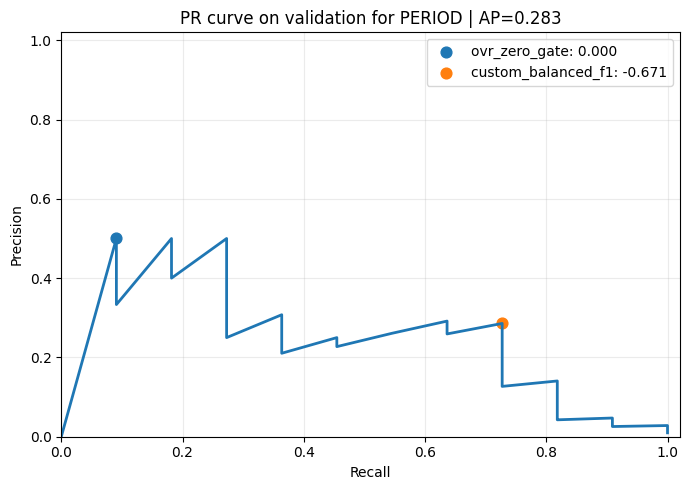

,threshold,precision,recall
0,-1.580501,0.009857,1.0
1,-1.555583,0.009865,1.0
2,-1.535519,0.009874,1.0
3,-1.500723,0.009883,1.0
4,-1.476022,0.009892,1.0
5,-1.455469,0.009901,1.0
6,-1.424319,0.009910,1.0
7,-1.418445,0.009919,1.0
8,-1.411034,0.009928,1.0
9,-1.403376,0.009937,1.0


Chosen custom threshold for PERIOD: -0.6706
Validation AP for PERIOD: 0.2829


In [13]:
from src.svm_experiments import decision_function_df
from src.threshold_eval import apply_ovr_threshold, evaluate_thresholds, plot_pr_curve

val_unbalanced_macro = float(
    best_svm_unbalanced_comparison.loc[
        best_svm_unbalanced_comparison["split"] == "val", "macro_f1"
    ].iloc[0]
)
val_balanced_macro = float(
    best_svm_balanced_comparison.loc[
        best_svm_balanced_comparison["split"] == "val", "macro_f1"
    ].iloc[0]
)

if val_balanced_macro >= val_unbalanced_macro:
    final_svm_model = best_svm_balanced_model
    final_svm_name = f"{best_svm_name} + class_weight=balanced"
    final_svm_class_weight = "balanced"
else:
    final_svm_model = best_svm_model
    final_svm_name = best_svm_name
    final_svm_class_weight = "none"

val_label_counts = val_df["dominant_label"].value_counts()
threshold_target_candidates = [
    label for label in tail_labels if val_label_counts.get(label, 0) >= 10
]
if threshold_target_candidates:
    threshold_target_label = threshold_target_candidates[0]
else:
    threshold_target_label = val_label_counts[val_label_counts >= 10].sort_values().index[0]

print(f"Final SVM for threshold analysis: {final_svm_name}")
print(
    f"Threshold target class: {threshold_target_label} | validation support={int(val_label_counts[threshold_target_label])}"
)
print(
    "Threshold policy: balanced precision/recall for a rare class, so choose the validation threshold "
    "that maximizes one-vs-rest F1 for the selected class."
)

val_scores_df = decision_function_df(final_svm_model, X_val, index=val_df["text_id"])
test_scores_df = decision_function_df(final_svm_model, X_test, index=test_df["text_id"])

candidate_thresholds = (
    val_scores_df[threshold_target_label]
    .sort_values()
    .drop_duplicates()
    .tolist()
)
threshold_search_val = evaluate_thresholds(
    y_true=y_val,
    scores_df=val_scores_df,
    target_label=threshold_target_label,
    thresholds=candidate_thresholds,
)

custom_threshold_row = (
    threshold_search_val[threshold_search_val["setting"] != "default_argmax"]
    .sort_values(["target_f1", "target_recall", "target_precision"], ascending=False)
    .iloc[0]
)
custom_threshold = float(custom_threshold_row["threshold"])

threshold_eval_val = evaluate_thresholds(
    y_true=y_val,
    scores_df=val_scores_df,
    target_label=threshold_target_label,
    thresholds={
        "ovr_zero_gate": 0.0,
        "custom_balanced_f1": custom_threshold,
    },
)
display(threshold_eval_val)

threshold_eval_test = evaluate_thresholds(
    y_true=y_test,
    scores_df=test_scores_df,
    target_label=threshold_target_label,
    thresholds={
        "ovr_zero_gate": 0.0,
        "custom_balanced_f1": custom_threshold,
    },
)
display(threshold_eval_test)

pr_curve_df, avg_precision = plot_pr_curve(
    y_true=y_val,
    scores=val_scores_df[threshold_target_label],
    positive_label=threshold_target_label,
    title=f"PR curve on validation for {threshold_target_label}",
    threshold_points={
        "ovr_zero_gate": 0.0,
        "custom_balanced_f1": custom_threshold,
    },
)
display(pr_curve_df.sort_values("threshold").head(10))

final_val_predictions = apply_ovr_threshold(
    scores_df=val_scores_df,
    target_label=threshold_target_label,
    threshold=custom_threshold,
)
final_test_predictions = apply_ovr_threshold(
    scores_df=test_scores_df,
    target_label=threshold_target_label,
    threshold=custom_threshold,
)

selected_model_name = final_svm_name
selected_model = final_svm_model
selected_model_features = best_svm_features
selected_model_class_weight = final_svm_class_weight
selected_threshold_target_label = threshold_target_label
selected_threshold_value = custom_threshold

print(f"Chosen custom threshold for {threshold_target_label}: {custom_threshold:.4f}")
print(f"Validation AP for {threshold_target_label}: {avg_precision:.4f}")

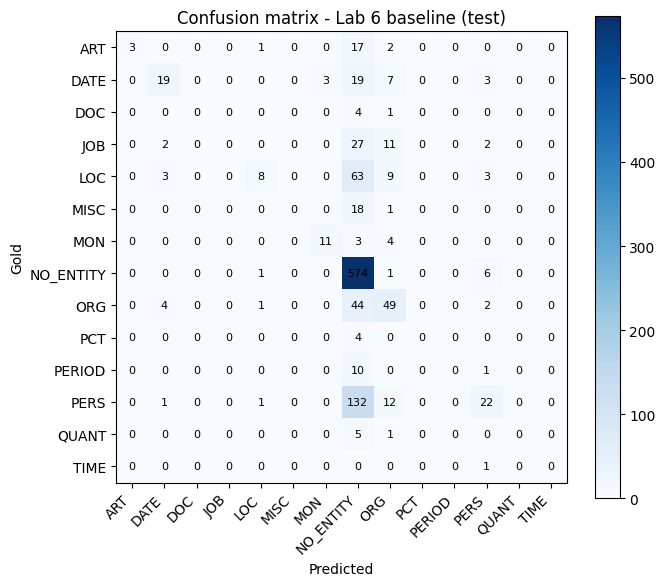

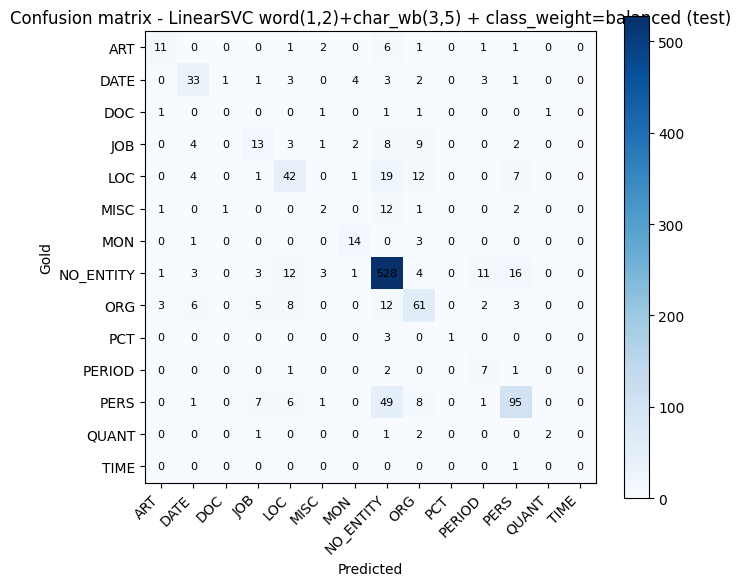

,gold_label,pred_label,count
33,PERS,NO_ENTITY,132
14,LOC,NO_ENTITY,63
26,ORG,NO_ENTITY,44
10,JOB,NO_ENTITY,27
4,DATE,NO_ENTITY,19
17,MISC,NO_ENTITY,18
1,ART,NO_ENTITY,17
34,PERS,ORG,12
11,JOB,ORG,11
29,PERIOD,NO_ENTITY,10


,gold_label,pred_label,count
63,PERS,NO_ENTITY,49
29,LOC,NO_ENTITY,19
47,NO_ENTITY,PERS,16
30,LOC,ORG,12
52,ORG,NO_ENTITY,12
42,NO_ENTITY,LOC,12
34,MISC,NO_ENTITY,12
46,NO_ENTITY,PERIOD,11
24,JOB,ORG,9
23,JOB,NO_ENTITY,8


,label,support,recall_baseline,correct_baseline,recall_final_svm,correct_final_svm,delta_recall
10,PERIOD,11,0.000000,0,0.636364,7,0.6364
11,PERS,168,0.130952,22,0.565476,95,0.4345
4,LOC,86,0.093023,8,0.488372,42,0.3953
0,ART,23,0.130435,3,0.478261,11,0.3478
12,QUANT,6,0.000000,0,0.333333,2,0.3333
3,JOB,42,0.000000,0,0.309524,13,0.3095
1,DATE,51,0.372549,19,0.647059,33,0.2745
9,PCT,4,0.000000,0,0.250000,1,0.2500
6,MON,18,0.611111,11,0.777778,14,0.1667
8,ORG,100,0.490000,49,0.610000,61,0.1200


Off-diagonal errors: baseline=430, final=307
Final model features: word(1,2)+char_wb(3,5) | class_weight=balanced
Threshold applied for PERIOD: -0.6706
Most frequent baseline confusions:
gold_label pred_label  count
      PERS  NO_ENTITY    132
       LOC  NO_ENTITY     63
       ORG  NO_ENTITY     44
       JOB  NO_ENTITY     27
      DATE  NO_ENTITY     19
      MISC  NO_ENTITY     18
       ART  NO_ENTITY     17
      PERS        ORG     12
       JOB        ORG     11
    PERIOD  NO_ENTITY     10
Most frequent final-model confusions:
gold_label pred_label  count
      PERS  NO_ENTITY     49
       LOC  NO_ENTITY     19
 NO_ENTITY       PERS     16
       LOC        ORG     12
       ORG  NO_ENTITY     12
 NO_ENTITY        LOC     12
      MISC  NO_ENTITY     12
 NO_ENTITY     PERIOD     11
       JOB        ORG      9
       JOB  NO_ENTITY      8


In [14]:
from sklearn.metrics import confusion_matrix


def confusion_df_from_predictions(y_true, preds, labels):
    matrix = confusion_matrix(y_true, preds, labels=labels)
    return pd.DataFrame(matrix, index=labels, columns=labels)


def top_confusion_pairs(cm_df: pd.DataFrame, top_k: int = 10) -> pd.DataFrame:
    rows = []
    for gold_label in cm_df.index:
        for pred_label in cm_df.columns:
            if gold_label == pred_label:
                continue
            count = int(cm_df.loc[gold_label, pred_label])
            if count > 0:
                rows.append(
                    {
                        "gold_label": gold_label,
                        "pred_label": pred_label,
                        "count": count,
                    }
                )

    if not rows:
        return pd.DataFrame(columns=["gold_label", "pred_label", "count"])

    return pd.DataFrame(rows).sort_values("count", ascending=False).head(top_k)


def per_class_recall_df(cm_df: pd.DataFrame, model_name: str) -> pd.DataFrame:
    rows = []
    for label in cm_df.index:
        support = int(cm_df.loc[label].sum())
        correct = int(cm_df.loc[label, label])
        recall = correct / support if support else 0.0
        rows.append(
            {
                "label": label,
                "support": support,
                f"recall_{model_name}": recall,
                f"correct_{model_name}": correct,
            }
        )
    return pd.DataFrame(rows)


test_labels_order = sorted(y_test.unique())
baseline_test_predictions = pd.Series(lab6_baseline.predict(X_test)).reset_index(drop=True)

if "final_test_predictions" in globals():
    final_test_predictions_series = pd.Series(final_test_predictions).reset_index(drop=True)
else:
    final_test_predictions_series = pd.Series(selected_model.predict(X_test)).reset_index(drop=True)

baseline_compare_cm_df = confusion_df_from_predictions(y_test, baseline_test_predictions, test_labels_order)
final_compare_cm_df = confusion_df_from_predictions(y_test, final_test_predictions_series, test_labels_order)

plot_confusion_df(baseline_compare_cm_df, "Confusion matrix - Lab 6 baseline (test)")
plot_confusion_df(final_compare_cm_df, f"Confusion matrix - {selected_model_name} (test)")

baseline_top_confusions_df = top_confusion_pairs(baseline_compare_cm_df, top_k=10)
final_top_confusions_df = top_confusion_pairs(final_compare_cm_df, top_k=10)
display(baseline_top_confusions_df)
display(final_top_confusions_df)

baseline_recall_df = per_class_recall_df(baseline_compare_cm_df, "baseline")
final_recall_df = per_class_recall_df(final_compare_cm_df, "final_svm")
recall_comparison_df = baseline_recall_df.merge(final_recall_df, on=["label", "support"], how="inner")
recall_comparison_df["delta_recall"] = (
    recall_comparison_df["recall_final_svm"] - recall_comparison_df["recall_baseline"]
).round(4)
display(recall_comparison_df.sort_values("delta_recall", ascending=False))

off_diag_baseline = int(baseline_compare_cm_df.values.sum() - baseline_compare_cm_df.values.diagonal().sum())
off_diag_final = int(final_compare_cm_df.values.sum() - final_compare_cm_df.values.diagonal().sum())
print(f"Off-diagonal errors: baseline={off_diag_baseline}, final={off_diag_final}")
print(f"Final model features: {selected_model_features} | class_weight={selected_model_class_weight}")
print(f"Threshold applied for {selected_threshold_target_label}: {selected_threshold_value:.4f}")

print("Most frequent baseline confusions:")
print(baseline_top_confusions_df.to_string(index=False))

print("Most frequent final-model confusions:")
print(final_top_confusions_df.to_string(index=False))

In [18]:
import re


def make_excerpt(text: str, max_len: int = 220) -> str:
    text = (text or "").strip()
    if len(text) <= max_len:
        return text
    return text[: max_len - 1].rstrip() + "..."


CONFUSABLE_ENTITY_PAIRS = {
    frozenset(["DATE", "PERIOD"]),
    frozenset(["DATE", "MON"]),
    frozenset(["QUANT", "MON"]),
    frozenset(["QUANT", "PCT"]),
    frozenset(["ORG", "LOC"]),
    frozenset(["ORG", "MISC"]),
    frozenset(["PERS", "JOB"]),
    frozenset(["PERS", "LOC"]),
    frozenset(["DOC", "ORG"]),
    frozenset(["ART", "MISC"]),
}


def detect_noise_or_variation(text: str) -> bool:
    text = text or ""
    has_cyr = bool(re.search(r"[А-Яа-яІіЇїЄєҐґ]", text))
    has_lat = bool(re.search(r"[A-Za-z]", text))
    has_quotes_or_apostrophe = any(ch in text for ch in ['"', "'", '`'])
    has_hyphenated_token = bool(re.search(r"\w[-/]\w", text))
    return (has_cyr and has_lat) or has_quotes_or_apostrophe or has_hyphenated_token


def guess_error_category(row: pd.Series) -> str:
    gold = row["gold_label"]
    pred = row["pred_label"]
    text = row["text"]
    margin = row["margin"]
    text_len = row["text_len"]
    gold_train_count = row["gold_train_count"]

    if selected_threshold_target_label in {gold, pred} and gold != pred:
        return "threshold_tradeoff"
    if text_len <= 40:
        return "short_text"
    if gold == "NO_ENTITY" and pred != "NO_ENTITY":
        return "false_positive_entity"
    if gold_train_count <= 50:
        return "class_imbalance"
    if detect_noise_or_variation(text):
        return "noise_or_name_variation"
    if pred != "NO_ENTITY" and gold != "NO_ENTITY" and frozenset([gold, pred]) in CONFUSABLE_ENTITY_PAIRS:
        return "overlap_classes"
    if pred == "NO_ENTITY" and gold != "NO_ENTITY":
        return "insufficient_context"
    if margin <= 0.15:
        return "overlap_classes"
    return "insufficient_context"


def build_error_comment(row: pd.Series) -> str:
    gold = row["gold_label"]
    pred = row["pred_label"]
    category = row["error_category"]
    gold_train_count = int(row["gold_train_count"])

    if category == "threshold_tradeoff":
        return (
            f"Поріг для {selected_threshold_target_label} зсуває баланс precision/recall: тут це дало перехід {gold} -> {pred}."
        )
    if category == "short_text":
        return "Текст дуже короткий, тому моделі бракує контексту для надійного типування сутності."
    if category == "false_positive_entity":
        return "Модель витягнула сутність із описового контексту, хоча в gold для цього text_id домінує NO_ENTITY."
    if category == "class_imbalance":
        return f"Gold-клас рідкісний у train ({gold_train_count} прикладів), тому сигнал для нього слабший і нестабільніший."
    if category == "noise_or_name_variation":
        return "Є варіативне написання, лапки, дефіси або змішаний формат токенів, що робить сигнал менш стабільним."
    if category == "overlap_classes":
        return f"Між класами {gold} та {pred} є близькі маркери, тому модель обрала сусідній тип сутності."
    return "В уривку мало явних підказок для gold-класу, тому модель скотилася до більш частого або простішого рішення."


if "final_test_predictions_series" in globals():
    selected_test_predictions = final_test_predictions_series.copy()
elif "final_test_predictions" in globals():
    selected_test_predictions = pd.Series(final_test_predictions).reset_index(drop=True)
else:
    selected_test_predictions = pd.Series(selected_model.predict(X_test)).reset_index(drop=True)

if "test_scores_df" not in globals():
    test_scores_df = decision_function_df(selected_model, X_test, index=test_df["text_id"])

error_analysis_all = test_df.copy().reset_index(drop=True)
error_analysis_all["pred_label"] = selected_test_predictions
error_analysis_all = error_analysis_all[error_analysis_all["dominant_label"] != error_analysis_all["pred_label"]].copy()
error_analysis_all = error_analysis_all.rename(columns={"dominant_label": "gold_label", "text_clean": "text"})

scores_for_errors = test_scores_df.reset_index(drop=True).loc[error_analysis_all.index].copy()
error_analysis_all["top_score"] = scores_for_errors.max(axis=1).to_numpy()
error_analysis_all["second_score"] = scores_for_errors.apply(lambda row: row.nlargest(2).iloc[-1], axis=1).to_numpy()
error_analysis_all["margin"] = (error_analysis_all["top_score"] - error_analysis_all["second_score"]).round(4)
error_analysis_all["text_len"] = error_analysis_all["text"].fillna("").str.len()
error_analysis_all["gold_train_count"] = error_analysis_all["gold_label"].map(train_df["dominant_label"].value_counts())
error_analysis_all["text_excerpt"] = error_analysis_all["text"].apply(make_excerpt)
error_analysis_all["error_category"] = error_analysis_all.apply(guess_error_category, axis=1)
error_analysis_all["comment"] = error_analysis_all.apply(build_error_comment, axis=1)
error_analysis_all["model_name"] = selected_model_name

display(error_analysis_all["error_category"].value_counts().rename_axis("error_category").reset_index(name="count"))

category_priority = [
    "threshold_tradeoff",
    "class_imbalance",
    "overlap_classes",
    "noise_or_name_variation",
    "short_text",
    "false_positive_entity",
    "insufficient_context",
]
per_category_quota = {
    "threshold_tradeoff": 2,
    "class_imbalance": 2,
    "overlap_classes": 2,
    "noise_or_name_variation": 2,
    "short_text": 1,
    "false_positive_entity": 2,
    "insufficient_context": 2,
}

selected_rows = []
used_ids: set[str] = set()
for category in category_priority:
    subset = error_analysis_all[error_analysis_all["error_category"] == category].sort_values(
        ["gold_train_count", "margin", "text_len", "text_id"], ascending=[True, True, True, True]
    )
    for _, row in subset.head(per_category_quota[category]).iterrows():
        if row["text_id"] in used_ids:
            continue
        selected_rows.append(row)
        used_ids.add(row["text_id"])

error_samples_lab7 = pd.DataFrame(selected_rows)
if len(error_samples_lab7) < 12:
    remaining = error_analysis_all[~error_analysis_all["text_id"].isin(used_ids)].sort_values(
        ["gold_train_count", "margin", "text_len", "text_id"], ascending=[True, True, True, True]
    )
    error_samples_lab7 = pd.concat([error_samples_lab7, remaining.head(12 - len(error_samples_lab7))], ignore_index=True)

error_samples_lab7 = error_samples_lab7[[
    "text_id",
    "text_excerpt",
    "gold_label",
    "pred_label",
    "error_category",
    "comment",
    "margin",
    "text_len",
    "gold_train_count",
]]
display(error_samples_lab7)

,error_category,count
0,noise_or_name_variation,122
1,insufficient_context,72
2,false_positive_entity,39
3,threshold_tradeoff,22
4,overlap_classes,21
5,short_text,19
6,class_imbalance,12


,text_id,text_excerpt,gold_label,pred_label,error_category,comment,margin,text_len,gold_train_count
660,text_6685,Про ці й інші проблеми протягом минулих років ...,PERIOD,LOC,threshold_tradeoff,Поріг для PERIOD зсуває баланс precision/recal...,0.1988,97,88
0,text_23,"А натомлені за день дівчата лягали на землю, п...",PERIOD,NO_ENTITY,threshold_tradeoff,Поріг для PERIOD зсуває баланс precision/recal...,0.4703,202,88
48,text_559,До десятої вечора Карий передивився альбом з ф...,TIME,PERS,class_imbalance,"Gold-клас рідкісний у train (7 прикладів), том...",0.9749,183,7
947,text_9424,Ця будівля стояла ще з радянських часів і була...,PCT,NO_ENTITY,class_imbalance,"Gold-клас рідкісний у train (31 прикладів), то...",0.1319,61,31
948,text_9444,Загальний дохід Солодченка за 2014 рік склав 1...,MON,DATE,overlap_classes,"Між класами MON та DATE є близькі маркери, том...",0.1602,106,144
1014,text_10112,Таким чином прокурор вимагав визнати недійсним...,JOB,DATE,overlap_classes,"Між класами JOB та DATE є близькі маркери, том...",0.0251,108,338
1047,text_10420,"При зарплаті у 144 тис грн у ТОВ ""Укрфармгруп""...",MON,ORG,noise_or_name_variation,"Є варіативне написання, лапки, дефіси або зміш...",0.1089,304,144
1063,text_10583,"""Полтавське управління геофізичних робіт ""кіль...",MON,ORG,noise_or_name_variation,"Є варіативне написання, лапки, дефіси або зміш...",0.2497,156,144
656,text_6634,Переважають багаторічні трави (51 %).,PCT,NO_ENTITY,short_text,"Текст дуже короткий, тому моделі бракує контек...",1.0088,37,31
843,text_8476,"Чи знає вона, як це - щодня розповідати її діт...",NO_ENTITY,PERS,false_positive_entity,Модель витягнула сутність із описового контекс...,0.0013,129,4657
